## HW 10

### Download dataset

In [1]:
import os
import requests
import zipfile

url = "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true"
zip_file_path = "WorldHappinessReport.zip"
csv_file_name = "chappiness_data.csv"

if not os.path.exists(csv_file_name):
    response = requests.get(url) 
    
    with open(zip_file_path, 'wb') as f:
        f.write(response.content)
        
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    os.remove(zip_file_path)

### Read datset

In [2]:
import pandas as pd
df = pd.read_csv('./2017.csv')

df.head(5)

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [11]:
df.info()
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    str    
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
 12  Cluster                        155 non-null    str    
 13  C

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485


### Check distribution 

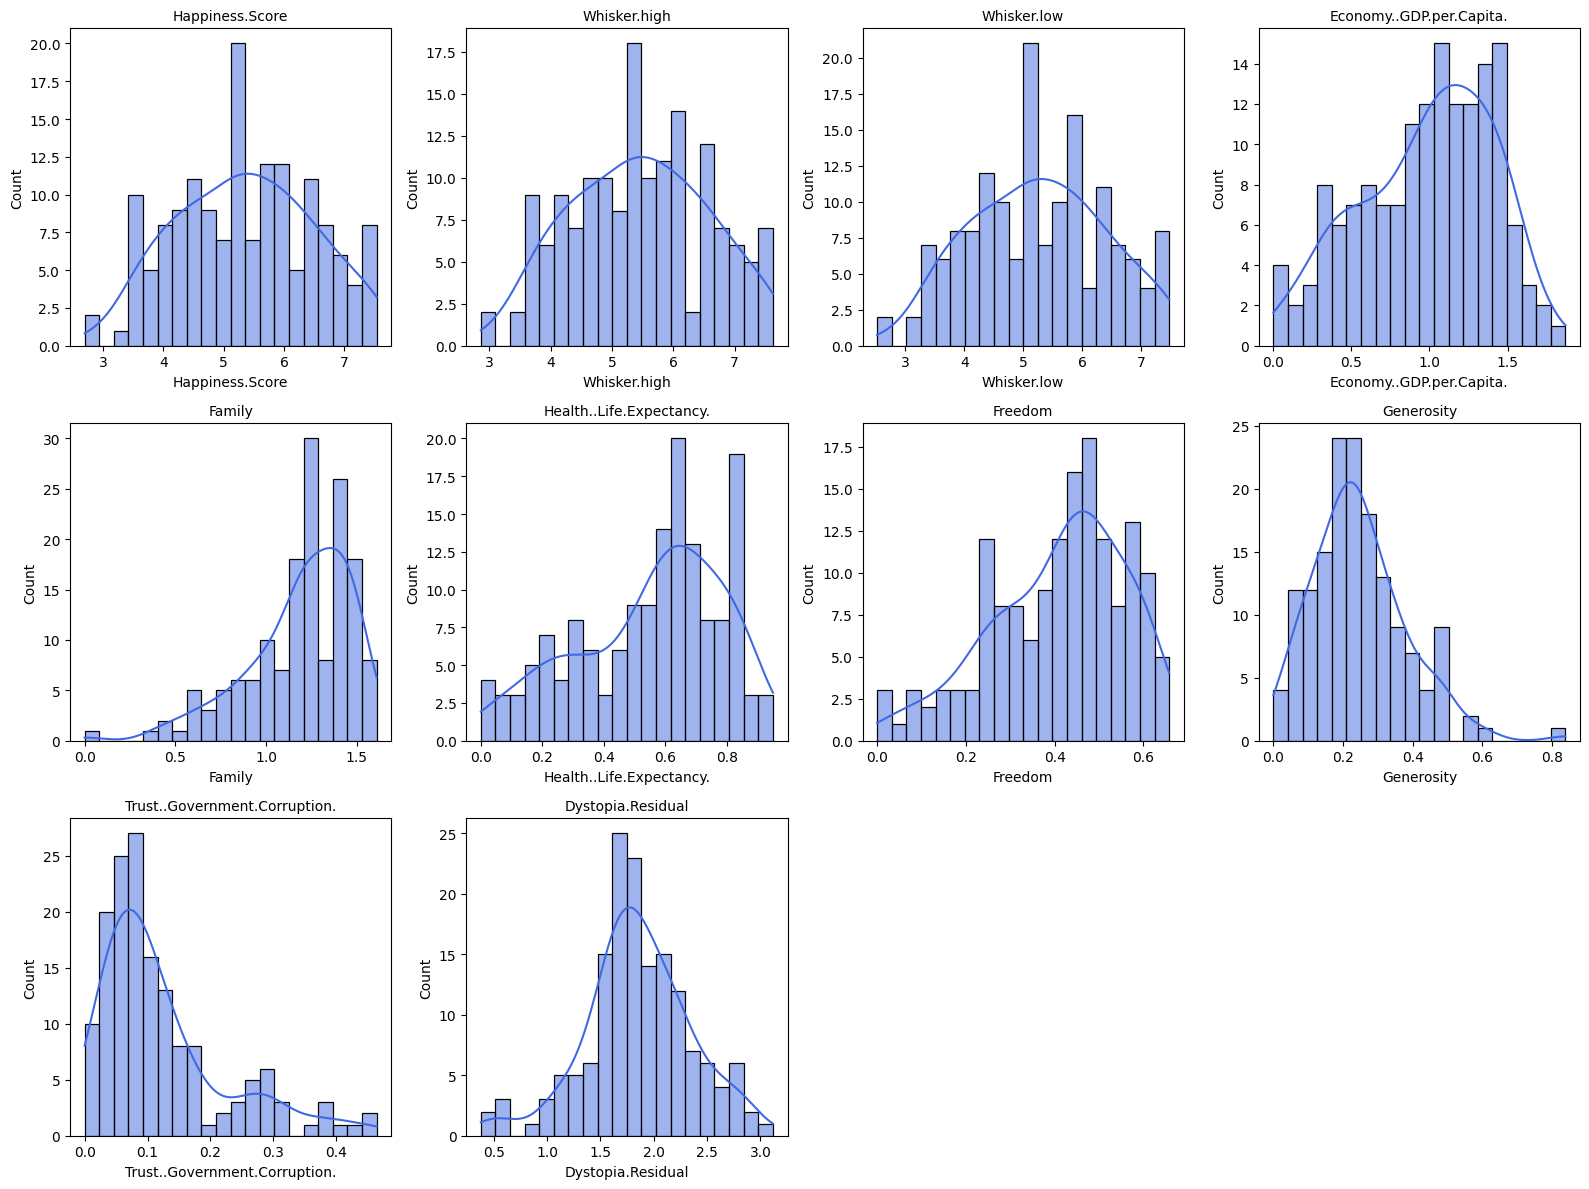

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only numerical columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
cols_to_plot = [col for col in numeric_cols if 'Rank' not in col]


plt.figure(figsize=(16, 12))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(3, 4, i) 
    
    sns.histplot(df[col], kde=True, bins=20, color='royalblue')
    
    plt.title(col, fontsize=10)


plt.tight_layout()
plt.show()

**Distribution analysis** showed that the target variable `Happiness.Score` and `Dystopia.Residual` have a distribution close to normal. 

Most social and economic factors have a strong asymmetry. `Trust` and `Generosity` are strongly skewed to the right, and `Family` and `Economy` are strongly skewed to the left. Since the GMM algorithm is based on the assumption of normality of the data, these skewed features can make it difficult for the algorithm to find optimal clusters.

### Correlation Matrix

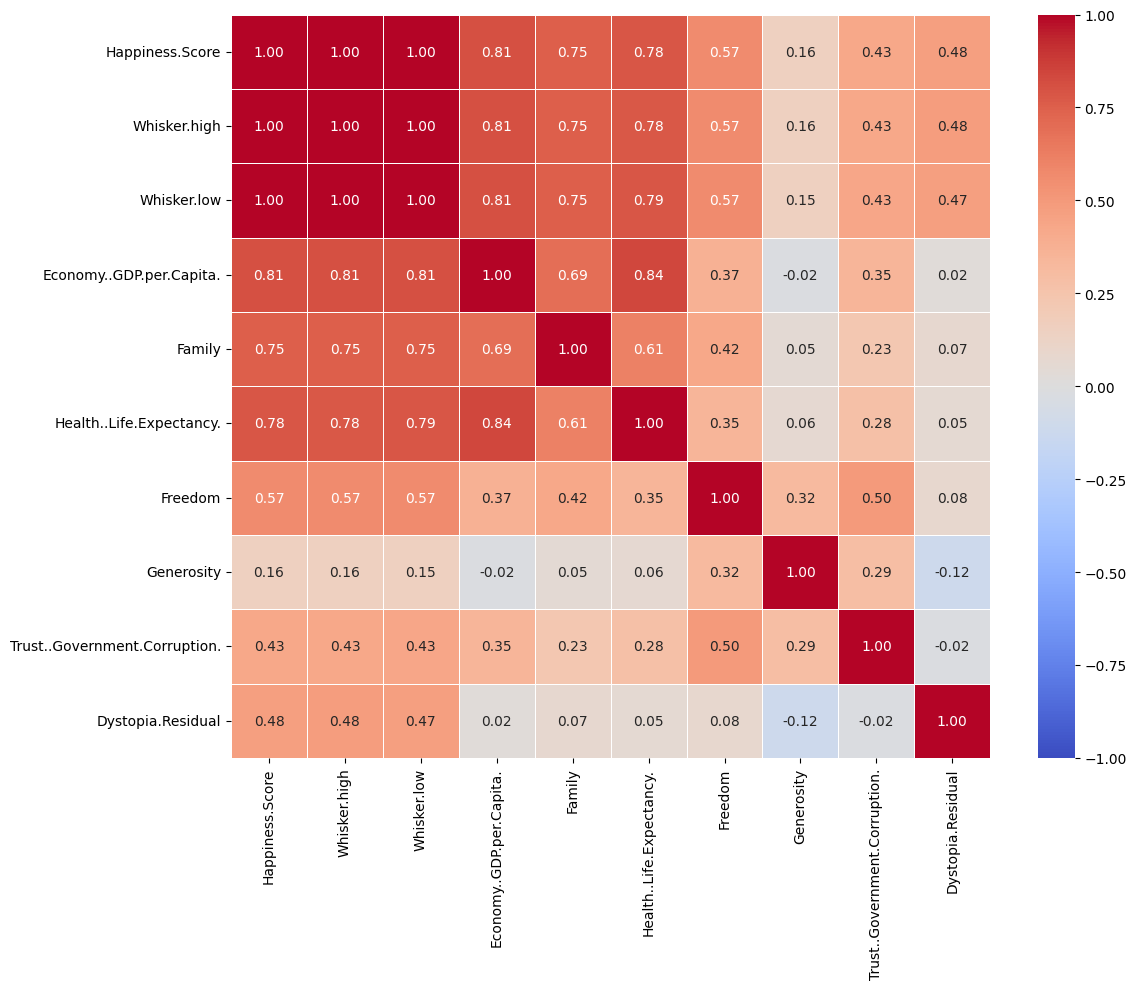

In [5]:
df_numeric = df[cols_to_plot]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.tight_layout()
plt.show()

**The correlation matrix analysis** revealed absolute collinearity (1.00) between `Happiness.Score` and `Whisker.high/low`. These variables are redundant and should be removed before modeling.

There is also a strong positive correlation (0.6 - 0.84) between economic indicators, health level and social support (Family), which indicates their complex impact on the overall level of happiness.

The indicators `Generosity` and `Trust` have the weakest connection with other features.

### Original Data Vizualization by Country

In [6]:
import plotly.express as px

fig = px.choropleth(df,
                    locations="Country",         
                    color="Happiness.Score",     
                    locationmode="country names"
                   )

fig.update_layout(title="Happiness Index 2017 (Original Data)")
fig.show()

/var/folders/rz/619jz5w17bv0qyf6x2ktyv340000gn/T/ipykernel_32031/3863292604.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df,


### Stadardization

In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

def data_scale(data, scaler_type='minmax'):
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()

    scaler.fit(data)
    res = scaler.transform(data)
    return res


cols_to_drop = ['Country', 'Happiness.Rank', 'Whisker.high', 'Whisker.low', 'Happiness.Score']
df_features = df.drop(columns=[c for c in cols_to_drop if c in df.columns])


data_scaled = data_scale(df_features, scaler_type='std')

df_scaled = pd.DataFrame(data_scaled, columns=df_features.columns)


print("Original:")
display(df_features.describe().loc[['mean', 'std', 'min', 'max']].round(3))

print("Standartized:")
display(df_scaled.describe().loc[['mean', 'std', 'min', 'max']].round(3))

Original:


,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
mean,0.985,1.189,0.551,0.409,0.247,0.123,1.850
std,0.421,0.287,0.237,0.150,0.135,0.102,0.500
min,0.000,0.000,0.000,0.000,0.000,0.000,0.378
max,1.871,1.611,0.949,0.658,0.838,0.464,3.117


Standartized:


,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
mean,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003
min,-2.348,-4.152,-2.333,-2.734,-1.838,-1.215,-2.954
max,2.112,1.473,1.685,1.669,4.401,3.367,2.543


**Comparing the statistics** shows that each column now has a mean of $\mu \approx 0$ and a standard deviation of $\sigma \approx 1$.

This evens out the effects of all factors on clustering so that the data become normally distributed.

### GMM

In [8]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)

cluster_labels = gmm.fit_predict(df_scaled)

df['Cluster'] = cluster_labels.astype(str)

print("Clusters:", df['Cluster'].unique())

Clusters: <StringArray>
['2', '0', '1']
Length: 3, dtype: str


In [9]:
fig_clusters = px.choropleth(df,
                             locations="Country",
                             color="Cluster",
                             locationmode="country names",
                             title="GMM Clusters ")

fig_clusters.show()

/var/folders/rz/619jz5w17bv0qyf6x2ktyv340000gn/T/ipykernel_32031/1424267382.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_clusters = px.choropleth(df,


**The cluster map** shows that the GMM algorithm was able to identify geographically and economically related regions without any knowledge of their coordinates. One cluster clearly covers developed countries (North America, Western Europe, Australia), another(2) - developing countries, and the third is concentrated mainly in Africa. This is broadly consistent with the original `Happiness.Score` distribution.

### Experiments

In [10]:
subset_features = ['Economy..GDP.per.Capita.', 'Health..Life.Expectancy.']

df_scaled_subset = df_scaled[subset_features]

gmm_subset = GaussianMixture(n_components=3, random_state=42)
df['Cluster_Econ_Health'] = gmm_subset.fit_predict(df_scaled_subset).astype(str)

fig_subset = px.choropleth(df,
                           locations="Country",
                           color="Cluster_Econ_Health",
                           locationmode="country names",
                           title="GMM Clusters (Economy & Healt)")

fig_subset.show()

/var/folders/rz/619jz5w17bv0qyf6x2ktyv340000gn/T/ipykernel_32031/527305723.py:8: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_subset = px.choropleth(df,


**When clustering only by economy and health**, the cluster boundaries changed. Some countries in Latin America or Eastern Europe could move to another cluster. This proves that social factors (Freedom, Social Support) have a significant weight in the GMM when forming the feature space.

### Conclusions

**Clustering quality:** GMM successfully performed with the task of country segmentation. The clustering results have a high visual correlation with the original Happiness.Score heatmap. 

**Data preparation:** The first analysis showed the presence of collinearity and skewness in the distributions. The use of `StandardScaler` was a critically necessary step, since GMM is based on calculating distances in a multidimensional space under the assumption of normality of the data. 

**Feature sensitivity:** An experiment with feature dimensionality reduction confirmed that the model is sensitive to the input data set. Excluding social metrics leads to a more “rigid” economic division of the world, which is less representative of the complex concept of “happiness.” 